# *Chapter 12* <br> Fourier Analysis; Signals and Filters

| | | |
|:---:|:---:|:---:|
| ![image](Figs/Cover.png)|[From **COMPUTATIONAL PHYSICS**, 3rd Ed, 2015](http://physics.oregonstate.edu/~rubin/Books/CPbook/index.html) <br>RH Landau, MJ Paez, and CC Bordeianu (deceased) <br>Copyrights: <br> [Wiley-VCH, Berlin;](http://www.wiley-vch.de/publish/en/books/ISBN3-527-41315-4/) and [Wiley & Sons, New York](http://www.wiley.com/WileyCDA/WileyTitle/productCd-3527413154.html)<br>  R Landau, Oregon State Unv, <br>MJ Paez, Univ Antioquia,<br> C Bordeianu, Univ Bucharest, 2015.<br> Support by National Science Foundation.|![image](Figs/BackCover.png)|

**12 Fourier Analysis: Signals & Filters**<br>
[12.1 Fourier Analysis of Nonlinear Oscillations](#12.1)<br>
[12.2 Fourier Series (Math)](#12.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.2.1 Examples: Sawtooth & Half-Wave
Functions](#12.2.1)<br>
[12.3 Exercise: Summation of Fourier Series](#12.3)<br>
[12.4 Fourier Transforms (Theory)](#12.4)<br>
[12.5 The Discrete Fourier Transform](#12.5)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.5.1 Aliasing (Assessment)](#12.5.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.5.2 Fourier Series DFT (Example)](#12.5.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.5.3 Assessments](#12.5.3)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.5.4 Nonperiodic Function DFT (Exploration)](#12.5.4)<br>
[12.6 Filtering Noisy Signals](#12.5.4)<br>
[12.7 Noise Reduction via Autocorrelation (Theory)](#12.7)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.7.1 Exercises](#12.7.1)<br>
[12.8 Filtering with Transforms (Theory)](#12.8)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.8.1 Digital Filters: Windowed Sinc Filters](#12.8.1)<br>
[12.9 The Fast Fourier Transform Algorithm (FFT)](#12.9)<br>
[12.9.1 Bit Reversal](#12.9.1)<br>
[12.10 FFT Implementation](#12.10)<br>
[12.11 FFT Assessment](#12.11)<br>

*In this chapter we examine Fourier series and Fourier transforms, two standard tools for decomposing periodic and nonperiodic motions. We find that as implemented for numerical
computation, both the series and the integral become a discrete
Fourier transform (DFT), which is simple to program. Latter in the chapter we
discuss the subject of signal filtering and see that various
Fourier tools can be used to reduce noise in measured or simulated
signals. We end the chapter with a discussion of the fast Fourier
transform (FFT), a technique that is so efficient that it permits
evaluations of DFTs in real time.*


**This Chapter’s Lecture & Slide Web Links**

| *Lecture*| *Slides* | *Sections*| *Lecture*|*Slides* | *Sections*| 
|- - - - |:- - -:|:- - -:| - - - - |:- - -:|:- - -:|
|[Fourier Analysis](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/Fourier_Intro/FourierIntro.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/FT_11Oct09.pdf)|10.1|[Discrete Fourier Transform I](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/DFT_I/DFT_I.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/DFT_03Nov09.pdf)|10.4|
|[DFT II](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/DFT_II/DFT_II.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/DFT_03Nov09.pdf)|10.4|[Filters](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/Filters/Filtering.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/Filter_20Nov09.pdf)|10.5|
|[DFT Aliasing](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/DFT_Alias/Alias.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pd/Allias_18Octt09.pdf)| 10.4.2| [Fast Fourier Transform](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/FFT/FFT.html)|[pdf](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/FFT_22Nov09.pdf)| 10.8|

## 12.1  Fourier Analysis of Nonlinear Oscillations <a id="12.1"></a>

[![image](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/Fourier_Intro/FourierIntro.html)

Consider a particle oscillating either in the nonharmonic potential of
(8.5):

$$\tag*{12.1} V(x) = \frac{1}{p} k |x|^{p}, \qquad p\neq 2,$$

or in the perturbed harmonic oscillator potential (8.2),

$$\tag*{12.2} V(x) = \frac{1}{2}kx^{2}\left(1 - \frac{2}{3}\alpha x\right).$$

While free oscillations in these potentials are always periodic, they
are not sinusoidal. Your **problem** is to take the solution of one of
these nonlinear oscillators and expand it in a Fourier basis:

$$\tag*{12.3} x(t) = A_{0} \sin(\omega t + \phi_{0}).$$

For example, if your oscillator is sufficiently nonlinear to behave like
the sawtooth function (Figure 12.1 A), then the Fourier spectrum you
obtain should be similar to that shown in Figure 12.1 B.

In general, when we undertake such a spectral analysis we want to
analyze the steady-state behavior of a system. This means that we have
waited for the initial transient behavior to die out. It is easy to
identify just what the initial transient is for linear systems, but may
be less so for nonlinear systems in which the “steady state” jumps among
a number of configurations. In the latter case we would have different
Fourier spectra at different times.

## 12.2  Fourier Series (Math) <a id="12.2"></a>

Part of our interest in nonlinear oscillations arises from their lack of
study in traditional physics courses where linear oscillations, despite
the fact that they are just a first approximation, are most often
studied. If the force on a particle is always toward its equilibrium
position (a restoring force), then the resulting motion will be
*periodic*, but not necessarily *harmonic*. A good example is the motion
in a highly anharmonic potential with $p \simeq 10$ in (12.1) that
produces an $x(t)$ looking like a series of pyramids; this motion is
periodic but not harmonic.

In a sense, our approach is the inverse of the traditional one in which
the *fundamental* oscillation is determined analytically and the
higher-frequency *overtones* are determined by perturbation theory
\[[Landau & Lifshitz(76)](BiblioLinked.html#LL)\]. We start with the full (numerical) periodic
solution and then decompose it into what may be called *harmonics.* When
we speak of fundamentals, overtones, and harmonics, we speak of
solutions to the linear *boundary-value problem*, for example, of waves
on a plucked violin string. In this latter case, and when given the
correct conditions (enough musical skill), it is possible to excite
individual harmonics or sums of them in the series

$$\tag*{12.4} y(t) = b_{0} \sin\omega_{0} t + b_{1} \sin {2\omega_{0} t} +
\cdots.$$

Anharmonic oscillators vibrate at a single frequency (which may vary
with amplitude) but not with a sinusoidal waveform. Although it is
mathematically proper to expand nonlinear oscillations in a Fourier
series, this does not imply that the individual harmonics can be excited
(played).

You may recall from classical mechanics that the general solution for a
vibrating system can be expressed as the sum of the *normal modes* of
that system. These expansions are possible only if we have *linear
operators* and, subsequently, the *principle of superposition*: If
$y_{1}(t)$ and $y_{2}(t)$ are solutions of some linear equation, then
$ \alpha_{1}y_{1}(t) +
\alpha_{2}y_{2}(t)$ is also a solution. The principle of linear
superposition does not hold when we solve nonlinear problems.
Nevertheless, it is always possible to expand a *periodic* solution of a
*nonlinear* problem in terms of trigonometric functions with frequencies
that are integer multiples of the true frequency of the nonlinear
oscillator.\[*Note:* We remind the reader that every periodic system by
definition has a period $T$ and consequently a true frequency $\omega$.
Nonetheless, this does not imply that the system behaves like
$\sin\omega t$. Only harmonic oscillators do that.\] This is a
consequence of *Fourier’s theorem* being applicable to any single-valued
periodic function with only a finite number of discontinuities. We
assume we know the period $T$, that is, that

$$\tag*{12.5} y(t+T) = y(t).$$

This tells us the *true frequency* $\omega$:

$$\tag*{12.6}
\omega \equiv \omega_1 =\frac{2\pi}{T}.$$

A periodic function (usually designated as the *signal*) can be expanded
as a series of harmonic functions with frequencies that are multiples of
the true frequency:

$$\tag*{12.7}
 y(t) = \frac{a_0}{2} + \sum_{n=1}^{\infty} \left(a_{n} \cos
n\omega t + b_{n} \sin n\omega t
\right).$$

This equation represents the signal $y(t)$ as the simultaneous sum of
pure tones of frequency $n\omega$. The coefficients $a_{n}$ and $b_{n}$
measure of the amount of $\cos n\omega t$ and $\sin
n\omega t$ present in $y(t)$ respectively. The intensity or power at
each frequency is proportional to $a_n^2+b_n^2$.

The Fourier series (12.7) is a “best fit” in the least-squares sense of
[Chapter 7, *Trial-and-Error Searching & Data Fitting*](CP07.ipynb),
because it minimizes $\sum_{i} [y(t_{i})-y_{i}]^{2}$, where $i$ denotes
different measurements of the signal. This means that the series
converges to the *average* behavior of the function, but misses the
function at discontinuities (at which points it converges to the mean)
or at sharp corners (where it overshoots). A general function $y(t)$ may
contain an infinite number of Fourier components, although low-accuracy
reproduction is usually possible with a small number of harmonics.

The coefficients $a_{n}$ and $b_{n}$ in (12.7) are determined by the
standard techniques for orthogonal function expansion. To find them,
multiply both sides of (12.7) by $\cos n\omega t$ or $\sin
n\omega t$, integrate over one period, and project a single $a_{n}$ or
$b_{n}$:

$$\tag*{12.8}
  {a_n\choose b_n} = \frac{2}{T} \int _{0}^{T} dt {\cos n\omega
t\choose \sin n\omega t} y(t), \quad \omega  =  \frac{2\pi}{T}.$$

As seen in the $b_n$ coefficients (Figure 12.1 right), these
coefficients usually decrease in magnitude as the frequency increases,
and can enter with a negative sign, the negative sign indicating
relative phase.

Awareness of the *symmetry* of the function $y(t)$ may eliminate the
need to evaluate all the expansion coefficients. For example,

- $a_{0}$ is twice the average value of $y$:
$$\tag*{12.9}
    a_{0} = 2 \left\langle y(t)\right\rangle.$$

-   For an *odd function*, that is, one for which $y(-t) = - y(t)$, all
    $a_{n}$ coefficients $\equiv 0$, and only half of the integration
    range is needed to determine $b_{n}$:

    $$\tag*{12.10}
    b_{n} = \frac{4}{T} \int _{0}^{T/2} dt\ y(t) \sin n\omega t.$$

    However, if there is no input signal for $t<0$, we do not have a
    truly odd function, and so small values of $a_n$ may occur.

-   For an *even function*, that is, one for which $y(-t) =
    y(t)$, all $b_{n}$ coefficient $\equiv 0$, and only half the
    integration range is needed to determine $a_{n}$:

    $$\tag*{12.11}
    a_{n} = \frac{4}{T} \int _{0}^{T/2} dt\ y(t) \cos n\omega t .$$

![image](Figs/Fig12_1.png)

**Figure 12.1** *Top:* A sawtooth function that repeats infinitely in time.
*Bottom:* The Fourier spectrum of frequencies contained in this function
(natural units). See too Figure 1.9 in which we show the result of summing a
finite number of terms of this series.

### 12.2.1  Examples: Sawtooth & Half-Wave Functions<a id="12.2.1"></a>

The sawtooth function (Figure 12.1) is described mathematically as

$$\tag*{12.12} y(t) =\begin{cases}
\frac{t}{T/2}, & for\ 0\leq t \leq \frac{T}{2},\
\frac{t-T}{ T/2}, & for \ \frac{T}{2} \leq t \leq T.
\end{cases}$$

It is clearly periodic, nonharmonic, and discontinuous. Yet it is also
odd and so can be represented more simply by shifting the signal to the
Top:

$$\tag*{12.13} y(t) = \frac{t}{T/2}, \quad -\frac{T}{2} \leq t \leq \frac{T}{2}.$$

Although the general shape of this function can be reproduced with only
a few terms of the Fourier components, many components are needed to
reproduce the sharp corners. Because the function is odd, the Fourier
series is a sine series and (12.8) determines the $b_n$ values:

$$\begin{align} \tag*{12.14}
b_{n} & =  \frac{2}{T} \int\limits_{-T/2}^{+T/2} dt  \sin n\omega t \frac{t} { T/2} =
\frac{2}{n\pi}(-1)^{n+1},  \\
\Rightarrow\quad    y(t) & =  \frac{2}{\pi} \left[\sin \omega t - \frac{1}{2} \sin 2\omega t + \frac{1}{3} \sin 3\omega t - \cdots
\right].\tag*{12.15}\end{align}$$

The half-wave function 

$$\tag*{12.16} 
y(t) =\begin{cases} \sin \omega t, & for  \ 0<t< T/2 , \\
 0, & for \ T/2 < t < T, \end{cases}$$

is periodic, nonharmonic (the upper half of a sine wave), and continuous, but
with discontinuous derivatives. Because it lacks the sharp corners of the
sawtooth function, it is easier to reproduce with a finite Fourier series. Equation
(12.8) determines 

$$\begin{align}
 a_{n} & =\begin{cases}
 \frac{-2}{\pi(n^2-1)}, & n\  \mbox{even or  0},\\
 0, & n\  \mbox{odd},\\
\end{cases}  \\
 b_{n} &=\begin{cases}
 \frac{1}{2}, & n = 1,\\
 0, & n \neq 1,
\end{cases}\\
\Rightarrow\quad    y(t) & =  \frac{1}{2} \sin \omega t +
\frac{1}{\pi} - \frac{2}{3\pi} \cos 2\omega t - \frac{2}{15\pi}
\cos 4 \omega t + .\tag*{12.17}\end{align}$$

## 12.3  Exercise: Summation of Fourier Series <a id="12.3"></a>

*Hint:* The program [**FourierMatplot.py**](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/FourierMatplot.py) written by Oscar Restrepo
performs a Fourier analysis of a sawtooth function and produces the
visualization shown on the right of Figure 1.9B. You may want to use
this program to help with this exercise.

1.  **Sawtooth function:** Sum the Fourier series for the *sawtooth
    function* up to order $n= 2, 4, 10, 20$, and plot the results over
    two periods.

    1.  Check that in each case the series gives the mean value of the
        function *at* the points of discontinuity.

    2.  Check that in each case the series *overshoots* by about 9% the
        value of the function on either side of the discontinuity (the
        *Gibbs phenomenon*).

2.  **Half-wave function:** Sum the Fourier series for the *half-wave
    function* up to order $n=2, 4, 10$,5 and plot the results over
    two periods. (The series converges quite well, doesn’t it?)

## 12.4  Fourier Transforms (Theory)<a id="12.4"></a>

[![image](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/DFT_II/DFT_II.html)

Although a Fourier *series* is the right tool for approximating or
analyzing periodic functions, the Fourier *transform* or *integral* is
the right tool for nonperiodic functions. We convert from series to
transform by imagining a system described by a continuum of
“fundamental” frequencies. We thereby deal with *wave packets*
containing continuous rather than discrete frequencies.\[*Note:* We
follow convention and consider time the function’s variable and
frequency the transform’s variable. Nonetheless, these can be reversed
or other variables such as position and wave vector may also be used.\]
While the difference between series and transform methods may appear
clear mathematically, when we approximate the Fourier integral as a
finite sum, the two become equivalent.

By analogy with (12.7), we now imagine our function or signal $y(t)$
expressed in terms of a continuous series of harmonics (*inverse Fourier
transform*):[{xml}](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/12.18.xml)

$$\tag*{12.18}
  y(t)    = \int_{-\infty}^{+\infty} d\omega\
Y(\omega)  \frac{e^{i\omega t}} {
\sqrt{2\pi}},$$

where for compactness we use a complex exponential function.\[*Note:*
Recall that $\exp(i\omega t) = \cos \omega t + i \sin
\omega t$, and with the law of linear superposition this means that the
real part of $y$ gives the cosine series, and the imaginary part the sine series.\]
The expansion amplitude $Y(\omega)$ is analogous to the Fourier coefficients
$(a_{n},b_{n})$, and is called the *Fourier transform* of $y(t)$. The integral
(12.18) is the inverse transform because it converts the transform to the signal.
The *Fourier transform* converts the signal $y(t)$ to its transform[{xml}](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/12.19.xml)

$Y(\omega)$:
$$\begin{align}
\tag*{12.19}
  Y(\omega) = \int_{-\infty}^{+\infty} dt
\frac{e^{-i\omega t}} {\sqrt{2\pi}} y(t) .\end{align}$$ 

The
$1/\sqrt{2\pi}$ factor in both these integrals is a common normalization
in quantum mechanics, but maybe not in engineering where only a single
$1/2\pi$ factor is used. Likewise, the signs in the exponents are also
conventions that do not matter as long as you maintain consistency.

If $y(t)$ is the measured response of a system (signal) as a function of
time, then $Y(\omega)$ is the *spectral function* that measures the
amount of frequency $\omega$ present in the signal. In many cases it
turns out that $Y(\omega)$ is a complex function with both positive and
negative values, and with powers-of-ten variation in magnitude.
Accordingly, it is customary to eliminate some of the complexity of
$Y(\omega)$ by making a semilog plot of the squared modulus
$\left| Y(\omega)\right|^{2}$ *versus* $\omega$. This is called a *power
spectrum* and provides an immediate view of the amount of power or
strength in each component.

If the Fourier transform and its inverse are consistent with each other, we
should be able to substitute (12.18) into (12.19) and obtain an identity:

$$\begin{align} \tag*{12.20}
Y(\omega) & =  \int_{-\infty}^{+\infty}\! dt  \frac{e^{-i\omega
t}}{\sqrt{2\pi}} \int_{-\infty}^{+\infty}    d\omega'
\frac{e^{i\omega' t}}{\sqrt{2\pi}} Y(\omega')  \\
&\!=\! \int_{-\infty}^{+\infty} d\omega'\left\{\int_{-\infty}^{+\infty}
dt \frac{e^{i(\omega'-\omega) t}}{2\pi} \right\}Y(\omega').\tag*{12.21}
 \end{align}$$

For this to be an identity, the term in braces must be the *Dirac delta
function*:

$$\tag*{12.22}
\int_{-\infty}^{+\infty} dt  e^{i(\omega'-\omega) t} = 2\pi
 \delta (\omega'-\omega).$$

While the delta function is one of the most common and useful functions
in theoretical physics, it is not well behaved in a mathematical sense
and misbehaves terribly in a computational sense. While it is possible
to create numerical approximations to $\delta(\omega' -\omega)$, they
may well be borderline pathological. It is certainly better for you to
do the delta function part of an integration analytically and leave the
nonsingular leftovers to the computer.

## 12.5  The Discrete Fourier Transform <a id="12.5"></a>

If $y(t)$ or $Y(\omega)$ is known analytically or numerically, the
integral (12.18) and (12.19) can be evaluated using the integration
techniques studied earlier. In practice, the signal $y(t)$ is measured
at just a finite number $N$ of times $t$, and these are all we have as
input to approximate the transform. The resultant [*discrete Fourier
transform*](http://www.science.oregonstate.edu/~rubin/Books/CPbook/eBook/GlossarySound/dft.wav)
is an approximation both because the signal is not known for all times,
and because we must integrate numerically \[[Briggs & Henson(95))](BiblioLinked.html#dft)\]. Once
we have a discrete set of (approximate) transform values, they can be
used to reconstruct the signal for any value of the time. In this way
the DFT can be thought of as a technique for interpolating, compressing,
and extrapolating the signal.

We assume that the signal $y(t)$ is sampled at $(N+1)$ discrete times ($N$
time intervals), with a constant spacing $\Delta t = h$ between times:

$$\begin{align} \tag*{12.23}
y_{k} & =  y(t_{k}),\qquad & k &=0,1,2,\ldots, N, \\
t_{k} &{ = } k h, \qquad &h  =\Delta t.\tag*{12.24}
\end{align}$$ 

In other words, we measure the signal
$y(t)$ once every $h^{th}$ of a second for a total time of $T$. This
correspondingly define the signal’s period $T$ and the *sampling rate* $s$:

 $$T= Nh, \qquad s = \frac{N}{T} = \frac{1}{h}.\tag*{12.25}$$

Regardless of the true
periodicity of the signal, when we choose a period $T$ over which to sample the
signal, the mathematics will inevitably produce a $y(t)$ that is periodic with
period $T$, 

$$\tag*{12.26}
 y(t+T) = y(t).$$ 
 
We recognize this periodicity, and ensure that there
are only $N$ independent measurements used in the transform, by defining the
first and last $y$’s to be equal:

$$\begin{align}
\tag*{12.27}
 y_0 = y_N.\end{align}$$
 
If we are analyzing a truly periodic
function, then the $N$ points should span one complete period, but not
more. This guarantees their independence. Unless we make further
assumptions, the $N$ independent data $y(t_{k})$ can determine no more
than $N$ independent transform values
$Y(\omega_{k}),   k= 0, \ldots, N$.

The time interval $T$ (which should be the period for periodic
functions) is the largest time over which we measure the variation of
$y(t)$. Consequently, it determines the lowest frequency contained in
our Fourier representation of $y(t)$,

$$\tag*{12.28}
\omega_1 = \frac{2 \pi}{T}.$$

The full range of frequencies in the spectrum $\omega_n$ are determined
by the number of samples taken, and by the total sampling time $T=Nh$ as

$$\tag*{12.29}
\omega_{n} = n \omega_1= n \frac{2\pi}{Nh}, \qquad n =0,
1,\ldots,N.$$

Here $\omega_0=0$ corresponds to the zero-frequency or DC component of
the transform, that is, the part of the signal that does not oscillate.

The discrete Fourier transform (DFT) algorithm follows from two
approximations. First we evaluate the integral in (12.19) from time $0$ to time
$T$, over which the signal is measured, and not from $-\infty$ to $+\infty$.
Second, the trapezoid rule is used for the integration\[*Note:* The alert reader
may be wondering what has happened to the $h/2$ with which the trapezoid
rule weights the initial and final points. Actually, they are there, but because we
have set $y_0\equiv y_N$, two $h/2$ terms have been added to produce one
$h$ term.\]:

$$\begin{align} \tag*{12.30}
Y(\omega_{n}) & =   \int_{-\infty}^{+\infty} dt
\frac{e^{-i\omega_{n} t}}{\sqrt{2\pi}} y(t) \simeq
\int_{0}^{T}dt  \frac{e^{-i\omega_{n} t}}{\sqrt{2\pi}} y(t), \\
&\simeq \sum_{k=1}^{N}h  y(t_{k})\frac{e^{-i\omega_{n}t_{k}}}{\sqrt{2\pi}} =\ h \sum_{k=1}^{N}y_{k}
\frac{e^{-2\pi i k n/N}}{\sqrt{2\pi}}. \tag*{12.31}\end{align}$$

To
keep the final notation more symmetric, the step size $h$ is factored
from the transform $Y$ and a discrete function $Y_{n}$ is defined:

$$\tag*{12.32}
Y_{n} { = } \frac{1}{h} Y(\omega_{n}) =    \sum_{k=1}^{N}y_{k}
\frac{e^{-2\pi i k n/N}} { \sqrt{2\pi}}, \qquad n = 0,1 \ldots, N. $$

With this same care in accounting, and with $d\omega\rightarrow
2\pi/Nh$, we invert the $Y_{n}$’s:

$$\begin{align} \tag*{12.33}
y(t) & { = } \int_{-\infty}^{+\infty} d\omega \frac{e^{i\omega t}}{\sqrt{2\pi}}
Y(\omega)\\
 \Rightarrow \quad y(t) &\simeq \sum_{n=1}^{N}
\frac{2\pi}{Nh}  \frac{e^{i \omega_{n}t}}{\sqrt{2\pi}}
Y(\omega_{n}). \tag*{12.34}
 \end{align}$$

Once we know the $N$ values of the transform, we can use (12.34) to
evaluate $y(t)$ for any time $t$. There is nothing illegal about
evaluating $Y_{n} $ and $y_{k}$ for arbitrarily large values of $n$ and
$k$, yet there is also nothing to be gained either. Because the
trigonometric functions are periodic, we just get the old answers:

$$\begin{align}
\tag*{12.35}
y(t_{k+N}) & = y((k+N)h)= y(t_{k}), \\
  Y(\omega_{n+N})  &= Y((n+N)\omega_1) = Y(\omega_{n}).\tag*{12.36}
 \end{align}$$

Another way of stating this is to observe that none of the equations
change if we replace $\omega_{n}t$ by $\omega_{n}t +
2\pi n$. There are still just $N$ independent output numbers for $N$
independent inputs, and so the transform and the reconstituted signal
are periodic.

We see from (12.29) that the larger we make the time $T=Nh$ over which
we sample the function, the smaller will be the frequency steps or
resolution.\[*Note:* See also §12.5.1 where we discuss the related
phenomenon of aliasing.\] Accordingly, if you want a smooth frequency
spectrum, you need to have a small frequency step $2\pi/T$, which means
a longer observation time $T$. While the best approach would be to
measure the input signal for all times, in practice a measured signal
$y(t)$ is often extended in time (“padded”) by adding zeros for times
beyond the last measured signal, which thereby increases the value of
$T$ artificially. Although this does not add new information to the
analysis, it does build in the experimentalist’s view that the signal
has no existence, or no meaning, at times after the measurements are
stopped.

While periodicity is expected for a Fourier *series*, it is somewhat
surprising for Fourier a *integral*, which have been touted as the right
tool for nonperiodic functions. Clearly, if we input values of the
signal for longer lengths of time, then the inherent period becomes
longer, and if the repeat period $T$ is very long, it may be of little
consequence for times short compared to the period. If $y(t)$ is
actually periodic with period $Nh$, then the DFT is an excellent way of
obtaining Fourier series. If the input function is not periodic, then
the DFT can be a bad approximation near the endpoints of the time
interval (after which the function will repeat) or, correspondingly, for
the lowest frequencies.

The discrete Fourier transform and its inverse can be written in a
concise and insightful way, and be evaluated efficiently, by introducing
a complex variable $Z$ for the exponential and then raising $Z$ to
various powers:[{xml}](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/12.37.xml),[{xml}](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/12.389.xml)

$$\begin{align}\tag*{12.37}
     y_{k} & = \frac{\sqrt{2\pi}} {N}\sum_{n=1}^{N} Z^{-nk} Y_{n}, \quad  Z =e^{-2\pi i/N}, \\
     Y_{n} &= \frac{1}{\sqrt{2\pi}} \sum_{k=1}^{N}  Z^{nk} y_{k},    \quad  Z^{nk} \equiv [(Z)^n]^k. \end{align}$$

With this formulation, the computer needs to compute only powers of $Z$. We
give our DFT code in Listing 12.1. If your preference is to avoid complex
numbers, we can rewrite (12.37) in terms of separate real and imaginary parts
by applying Euler’s theorem with $\theta { = } {2\pi/ N}$:

$$\begin{align}
\tag*{12.39}
Z  = e^{-i\theta}, \quad
  & \Rightarrow\   Z^{\pm nk} = e^{\mp
ink\theta} = \cos nk\theta \mp i \sin nk\theta,\\
  \Rightarrow \quad Y_{n} &=  \frac{1}{\sqrt{2\pi}} \sum_{k=1}^{N} \left[(\cos
(nk\theta)\mbox{Re}  y_k +\sin (nk\theta)  \mbox{Im }y_k
\right.  \\
 & \quad \left. +   \mathbf{i} (\cos (nk\theta)  \mbox{Im }y_k -\sin
(nk\theta)\mbox{Re} y_k)\right],\tag*{12.40}\\
y_{k} &=
\frac{\sqrt{2\pi}}{N}\sum_{n=1}^{N} \left[(\cos (nk\theta) \mbox{Re} Y_n -\sin
(nk\theta) \mbox{Im } Y_n\right. \\
& \quad \left. + \mathbf{i} (\cos
(nk\theta)\mbox{Im } Y_n +\sin (nk\theta) \mbox{Re} Y_n ) \right].\tag*{12.41}\end{align}$$

Readers new to DFT’s are often surprised when they apply these equations
to practical situations and end up with transforms $Y$ having imaginary
parts, despite the fact that the signal $y$ is real. Equation (12.41)
should make it clear that a real signal ($\mbox{Im }y_k \equiv 0$) will
yield an imaginary transform unless
$\sum_{k=1}^{N}\sin (nk\theta)  \mbox{Re } y_k =
0$. This occurs only if $y(t)$ is an *even* function over
$-\infty \leq t \leq +\infty$ *and* we integrate exactly. Because
neither condition holds, the DFT’s of real, even functions may have
small imaginary parts. This is not as a result of an error in
programming, and in fact is a good measure of the approximation error in
the entire procedure.

The computation time for a discrete Fourier transform can be reduced
even further by use of the [*fast Fourier
transform*](http://www.science.oregonstate.edu/~rubin/Books/CPbook/eBook/GlossarySound/fft.wav)
algorithm, as discussed in § 12.9. An examination of (12.37) shows that
the DFT is evaluated as a matrix multiplication of a vector of length
$N$ containing the $Z$ values by a vector of length $N$ of $y$ value.
The time for this DFT scales like $N^{2}$, while the time for the FFT
algorithm scales as $N \log_{2} N$. Although this may not seem like much
of a difference, for $N=10^{2-3}$, the difference of $10^{3-5}$ is the
difference between a minute and a week. For this reason, it is the FFT
is often used for on-line spectrum analysis.

[**Listing 12.1  DFTcomplex.py**](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/DFTcomplex.py) uses the built-in complex numbers of Python
to compute the discrete Fourier transform for the signal in method f(signal).

### DFTcomplex.py, Notebook Version

In [ ]:
# DFTcomplex, Notebook Version

from IPython.display import IFrame
from numpy import *
import numpy as np
import matplotlib.pyplot as plt

N = 1000
Np = N                           # Number points
signal = zeros( (N+1), float )     
twopi  = 2.*pi
sq2pi = 1./sqrt(twopi)
h = twopi/N
dftz = zeros( (Np), complex )    # sequence complex elements
signal=np.zeros( (N+1), float)   # Original signal
trimag=np.zeros( (N+1), float)   # Imaginary part transform
trreal=np.zeros( (N+1), float)   #  Real part transform
xx=np.zeros((N+1),float)
ytri=[]
xtri=[]
ytre=[]
xtre=[]
def f(signal):                                                      # signal function
    step = twopi/N
    x = 0. 
    for i in range(0, N+1):
        signal[i] = (1+2*sin(x+2)+3*sin(4*x+2))*(1+2*sin(x+2)
                    + 3*sin(4*x + 2.))
        xx[i]=x
        x += step
f(signal) 

def fourier(dftz,xtri,ytri,xtre,ytre):           # DFT
    #global yist,hist
    for n in range(0, Np):              
        zsum = complex(0.0, 0.0)         # real and imag parts = zero
        for  k in range(0, N):                 # loop for sums
            zexpo = complex(0, twopi*k*n/N)    # complex exponent
            zsum += signal[k]*exp(-zexpo)      # Fourier transform core
        dftz[n] = zsum * sq2pi                 # factor
        ar=dftz[n].real
        trreal[n]=ar
        if dftz[n].imag >0.01:            # plot if not too small imag
            trimag[n]=dftz[n].imag        # plot bars
            xtri=xtri+[n]
            ytri=ytri+[trimag[n]]
            #print(n,yhist)
        if (dftz[n].real > 0.01 and n<900):    # plot the real part
            trreal[n]=dftz[n].real 
            xtre=xtre+[n]
            ytre=ytre+[trreal[n]]
            #print(n,trreal[n])
    return xtri,ytri,xtre,ytre        
xtri,ytri,xtre,ytre=fourier(dftz,xtri,ytri,xtre,ytre) 
fig=plt.figure()
ax1=fig.add_subplot(3,1,1)  
ax1.plot(xx,signal,'r')

plt.title('Signal')
plt.xlabel('x')
plt.ylabel('signal')
plt.tight_layout()

ax2=fig.add_subplot(3,1,2)
ax2.bar(xtri,ytri,0.1)
plt.title('Imaginary part transform')
plt.ylabel('Imag')

ax3=fig.add_subplot(3,1,3)
ax3.bar(xtre,ytre,0.1)
plt.title('Real part transform')
plt.xlabel('frequency')
plt.ylabel('Real')
plt.tight_layout()

plt.show()

### 12.5.1  Aliasing (Assessment)<a id="12.5.1"></a>

[![image](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/DFT_Alias/Alias.html)

The sampling of a signal by DFT for only a finite number of times (large
$\Delta t$) limits the accuracy of the deduced high-frequency components
present in the signal. Clearly, good information about very high
frequencies requires sampling the signal with small time steps so that
all the wiggles can be included. While a poor deduction of the
high-frequency components may be tolerable if all we care about are the
low-frequency components, the inaccurate high-frequency components
remain present in the signal and may contaminate the low-frequency
components that we deduce. This effect is called *aliasing* and is the
cause of the Moiré pattern distortion in digital images.

As an example, consider Figure 12.2 showing the two functions
$\sin(\pi t/2)$ and $\sin(2\pi t)$ for $0\le t\le 8$, with their points
of overlap in bold. If we were unfortunate enough to sample a signal
containing these functions at the times $t= 0, 2, 4, 6, 8,$ then we
would measure $y\equiv 0$ and assume that there was no signal at all.
However, if we were unfortunate enough to measure the signal at the
filled dots in Figure 12.2 where $\sin(\pi t/2) =\sin(2\pi t)$,
specifically, $t= 0, \frac{12}{10}, \frac{4}{3}, \ldots$, then our
Fourier analysis would completely miss the high-frequency component. In
DFT jargon, we would say that the high-frequency component has been
*aliased* by the low-frequency component. In other cases, some
high-frequency values may be included in our sampling of the signal, but
our sampling rate may not be high enough to include enough of them to
separate the high-frequency component properly. In this case some
high-frequency signals would be included spuriously as part of the
low-frequency spectrum, and this would lead to spurious low-frequency
oscillations when the signal is synthesized from its Fourier components.

![image](Figs/Fig12_2.png)

**Figure 12.2** A plot of the functions $\text{sin(}\pi
\textit{t}\text{/2)}$ and $\text{sin(2}\pi
\textit{t}\text{ )}$. If the sampling rate is not high enough, these
signals may appear indistinguishable in a Fourier decomposition. If the
sample rate is too low and if both signals are present in a sample, the
deduced low-frequency component may be contaminated by the
higher-frequency component signal.

More precisely, aliasing occurs when a signal containing frequency $f$
is sampled at a rate of $s=N/T$ measurements per unit time, with
$s\leq f/2$. In this case, the frequencies $f$ and $f-2s$ yield the same
DFT, and we would not be able to determine that there are two
frequencies present. That being the case, to avoid aliasing we want no
frequencies $f > s/2$ to be present in our input signal. This is known
as the *Nyquist criterion*. In practice, some applications avoid the
effects of aliasing by filtering out the high frequencies from the
signal and then analyzing only the remaining low-frequency part. (The
low-frequency *sinc filter* discussed in §12.8.1 is often used for this
purpose.) Although filtering eliminates some high-frequency information,
it lessens the distortion of the low-frequency components, and so may
lead to improved reproduction of the signal.

If accurate values for the high frequencies are required, then we will
need to increase the sampling rate $s$ by increasing the number $N$ of
samples taken within the fixed sampling time $T=Nh$. By keeping the
sampling time constant and increasing the number of samples taken, we
make the time step $h$ smaller and we pick up the higher frequencies. By
increasing the number $N$ of frequencies that you compute, you move the
previous higher-frequency components in closer to the middle of the
spectrum, and thus away from the error-prone ends.

If we increase the total time sampling time $T=Nh$ and keep $h$ the
same, then the sampling rate $s=N/T = 1/h$ remains the same. Because
$\omega_1= 2 \pi/ T$, this makes $\omega_1$ smaller, which means we have
more low frequencies recorded and a smoother frequency spectrum. And as
we said, this is often carried out, after the fact, by padding the end
of the data set with zeros.

[**Listing 12.2  DFTreal.py**](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/DFTreal.py) computes the discrete Fourier transform for the
signal in method `f(signal)` using real numbers.

In [ ]:
### DFTreal.py, Notebook Version

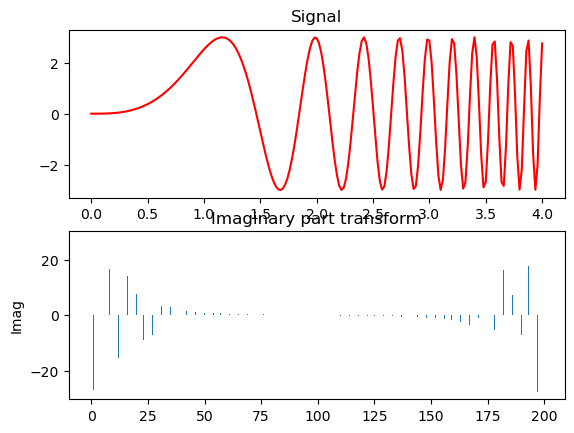

In [1]:
# DFTreal.py, Notebook Version
 
#from numpy import *
import numpy as np
import matplotlib.pyplot as plt

N = 200
Np = N                           # Number points
signal = np.zeros( (N+1), float )  
twopi  = 2.*np.pi
sq2pi = 1./np.sqrt(twopi)
#print("ra ",sq2pi)
h = twopi/N
dftimag = np.zeros((Np),float)   # contains im. part of transform
tt=np.zeros((N+1),float)
ytri=[]
xtri=[]

def f(signal):                 # initial function
    step = 4./N
    t= 0. 
    for  i in range(0,N+1):
        signal[i] = 3*np.sin(t**3)  
        tt[i]=t
        t += step
def fourier(dftimag,xtri,ytri):            # Discrete Fourier Transform
    for n in range(0,Np):                   # over frequency
        imag = 0.                           # reset  variables
        for  k in range(0, N):              # loop for sums
            imag += signal[k]*np.sin(twopi*k*n/N) 
        dftimag[n] = -imag*sq2pi            # imag. part transform
        #if abs(dftimag[n]) >1 and n<100:                  # to plot if not too small trnsf
        xtri=xtri+[n]
        ytri=ytri+[dftimag[n]]
            
            #impart.plot(pos=(n,dftimag[n]))      # plot bars
    return xtri,ytri
f(signal) 
fig=plt.figure()
ax1=fig.add_subplot(2,1,1)  
plt.title('Signal')
ax1.plot(tt,signal,'r')
xtri,ytri=fourier(dftimag,xtri,ytri)
#print(ytri)
ax2=fig.add_subplot(2,1,2)
ax2.bar(xtri,ytri,0.1)
plt.title('Imaginary part transform')
plt.ylabel('Imag')
plt.show()

### 12.5.3  Assessments<a id="12.5.3"></a>

**Simple analytic input**: It is always good to do simple checks before examining more complex
    problems, even if you are using a package’s Fourier tool.

1. Sample the even signal

    $$\tag*{12.47} y(t) = 3\cos(\omega t) + 2 \cos(3\omega t) + \cos(5\omega t).$$
 
 1.  Decompose this into its components.
 2.  Check that the components are essentially real and in the ratio 3:2:1 (or 9:4:1 for the power spectrum)
 3.  Verify that the frequencies have the expected values (not just ratios).
 4.  Verify that the components resum to give the input signal.
 5.  Experiment on the separate effects of picking different values of the step size $h$ and of enlarging the measurement period $T=Nh$.
 
2.  Sample the odd signal

    $$\tag*{12.48}  y(t) = \sin(\omega t) + 2 \sin(3\omega t) + 3\sin(5\omega t).$$    
    
    Decompose this into its components; then check that they are essentially imaginary and in the ratio 1:2:3 (or 1:4:9 if a power spectrum is plotted) and that they resum to give the input signal.

3.  Sample the mixed-symmetry signal

    $$\tag*{12.49}  y(t) = 5\sin(\omega t) + 2 \cos(3\omega t) + \sin(5\omega t).$$  
    
    Decompose this into its components; then check that there are         three of them in the ratio 5:2:1 (or 25:4:1 if a power spectrum         is plotted) and that they resum to give the input signal.

4.  Sample the signal

$$\begin{align}         y(t) = 5 +10 \sin(t +2).\end{align}$$  

Compare and explain the results obtained by sampling (a) without   the 5, (b) as given but  without the 2, and (c) without the 5 and          without the 2.

5.  In our discussion of aliasing, we examined Figure 12.2 showing the functions $\sin(\pi t/2)$ and $\sin(2\pi t)$. Sample the function

    $$\tag*{12.50}  y(t) = \sin\left(\frac{\pi}{2}t\right) + \sin(2\pi t)$$   and explore how aliasing occurs. Explicitly, we know that the         true transform contains peaks at $\omega=\pi/2$ and         $\omega = 2 \pi$. Sample the signal at a rate that leads to         aliasing, as well as at a higher sampling rate at which there is         no aliasing. Compare the resulting DFT’s in each case and check if your conclusions agree with the Nyquist criterion.

**Highly nonlinear oscillator:**:   Recall the numerical solution for oscillations of a spring with power $p=12$ \[see (12.1)\]. Decompose the solution into a Fourier series and determine the number of higher harmonics that contribute at least $10\%$; for example, determine the $n$ for which $|b_{n}/b_{1}| < 0.1$. Check that resuming the components reproducesthe signal.

**Nonlinearly perturbed oscillator**:   Remember the harmonic oscillator with a nonlinear perturbation (8.2):

$$\tag*{12.51}
    V(x) = \frac{1}{2}kx^{2}(1 - \frac{2}{3}\alpha x ) ,
    \qquad F(x) = -kx (1 -\alpha x).$$

For very small amplitudes of oscillation ($x \ll 1/\alpha$), the solution $x(t)$ essentially should be only the first term of a Fourier series.

1.  We want the signal to contain “approximately 10% nonlinearity.”         This being the case, fix your value of $\alpha$ so that         $\alpha x_{\text{max}} \simeq 10\%$, where $x_{\text{max}}$ is the         maximum amplitude of oscillation. For the rest of the problem, keep the value of $\alpha$ fixed.

2.  Decompose your numerical solution into a discrete Fourier spectrum.

3.  Plot a graph of the percentage of importance of the first *two*, non-DC Fourier components as a function of the initial         displacement for $0< x_{0} <1/2\alpha$. You should find that         higher harmonics are more important as the amplitude increases.         Because both even and odd components are present, $Y_n$ should         be complex. Because a 10% effect in amplitude becomes a 1%         effect in power, make sure that you make a semilog plot of the         power spectrum.

4.  As always, check that resumations of your transforms reproduce         the signal.

(*Warning:* The $\omega$ you use in your series must correspond to the
*true* frequency of the system, not the $\omega_0$ of small
oscillations.)

### 12.5.2  Fourier Series DFT (Example)<a id="12.5.2"></a>

For simplicity let us consider the Fourier cosine series:

$$\tag*{12.42} y(t) = \sum_{n=0}^{\infty} a_{n} \cos(n\omega t), \quad a_{k} =
\frac{2}{T} \int_{0}^{T} dt \cos(k\omega t) y(t).$$

Here $T = 2\pi/\omega $ is the actual period of the system (not
necessarily the period of the simple harmonic motion occurring for a
small amplitude). We assume that the function $y(t)$ is sampled for a
discrete set of times

$$\tag*{12.43} y(t=t_{k}) \equiv y_{k}, \quad k =0, 1, \ldots, N.$$

Because we are analyzing a periodic function, we retain the conventions
used in the DFT and require the function to repeat itself with period
$T=Nh$; that is, we assume that the amplitude is the same at the first
and last points:

$$\tag*{12.44}
 y_0 = y_N.$$

This means that there are only $N$ independent values of $y$ being used
as input. For these $N$ independent $y_{k}$ values, we can determine
uniquely only $N$ expansion coefficients $a_{k}$. If we use the
trapezoid rule to approximate the integration in (12.42), we determine
the $N$ independent Fourier components as

$$\begin{align}
\tag*{12.45}
a_{n} \simeq \frac{2h}{T} \sum_{k=1}^N \cos\left(n\omega t_k\right) y(t_k) & =
\frac{2}{N} \sum_{k=1}^N \cos\left( \frac{2\pi n k}{N} \right)y_k,\ && n=
0,\ldots , N.\end{align}$$

Because we can determine only $N$ Fourier components from $N$
independent $y(t)$ values, our Fourier series for the $y(t)$ must be in
terms of only these components:

$$\tag*{12.46} y(t) \simeq \sum_{n=0}^{N} a_{n} \cos(n\omega t) =
\sum_{n=0}^{N} a_{n} \cos\left(\frac{2\pi nt} { Nh}\right).$$

In summary, we sample the function $y(t)$ at $N$ times, $t_1$, $\ldots$
, $t_N$. We see that all the values of $y$ sampled contribute to each
$a_{k}$. Consequently, if we increase $N$ in order to determine more
coefficients, we must recompute all the $a_{n}$ values. In the wavelet
analysis in [Chapter 13, *Wavelet Analysis: Nonstationary Signals & Data
Compression*](CP13.ipynb), the theory is reformulated so that additional
samplings determine higher spectral components without affecting lower
ones.

### 12.5.4 Function DFT (Exploration)<a id="12.5.4"></a>

[![image](Figs/PythonCode1.png)](http://www.science.oregonstate.edu/~rubin/Books/CPbook/eBook/GlossarySound/FFTapplic.html)

Consider a simple model (a wave packet) of a “localized” electron moving
through space and time. A good model for an electron initially localized around
$x=5$ is a Gaussian multiplying a plane wave:
$$\tag*{12.52}
 \psi(x,t=0) = \exp\left[-\frac{1}{2}\left(\frac{x-5.0}{\sigma_0}
\right)^2\right] e^{ik_0x}.$$
This wave packet is not an eigenstate of
the momentum operator  $p=id/dx$ and in fact contains a spread of momenta. [*Note:* We use natural units in which $\hbar=1$.] Your **problem** is to evaluate the Fourier transform,

$$\tag*{12.53}
\psi(p) = \int_{-\infty} ^{+\infty}
 dx \frac{e^{ipx}}{\sqrt{2\pi}} \psi(x),$$

as a way of determining the momenta components in (12.52).

## 12.6  Filtering Noisy Signals <a id="12.6"></a>

[![image](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/Filters/Filters.html)

You measure a signal $y(t)$ that obviously contains noise. Your
**problem** is to determine the frequencies that would be present in the
spectrum of the signal if the signal did not contain noise. Of course,
once you have a Fourier transform from which the noise has been removed,
you can transform it to obtain a signal $s(t)$ with no noise.

*In the process of solving this problem we examine two simple
approaches: the use of autocorrelation functions and the use of filters.
Both approaches find wide applications in science, with our discussion
not doing the subjects justice. We will see filters again in the
discussion of wavelets in [Chapter 13, *Wavelet Analysis: Nonstationary
Signals & Data Compression*.](CP13.ipynb)*

## 12.7  Noise Reduction via Autocorrelation (Theory) <a id="12.7"></a>

We assume that the measured signal is the sum of the true signal $s(t)$,
which we wish to determine, plus some unwelcome *noise* $n(t)$:

$$\tag*{12.54} y(t) = s(t) + n(t).$$

Our first approach at removing the noise relies on that fact that noise
is a random process and thus should not be correlated with the signal.
Yet what do we mean when we say that two functions are not *correlated?*
Well, if the two tend to oscillate with their nodes and peaks in much
the same places, then the two functions are clearly correlated. An
analytic measure of the correlation of two arbitrary functions $y(t)$
and $x(t)$ is the *correlation function*

$$\tag*{12.55} c(\tau) = \int_{-\infty}^{+\infty} dt\ y^*(t) x(t+\tau) \equiv
\int_{-\infty}^{+\infty} dt  y^*(t-\tau)  x(t),$$

where $\tau$, the *lag time*, is a variable. Even if the two signals
have different magnitudes, if they have similar time dependences except
for one lagging or leading the other, then for certain values of $\tau$
the integrand in (12.55) will be positive for all values of $t$. For
those values of $\tau$ the two signals interfere constructively and
produce a large value for the correlation function. In contrast, if both
functions oscillate independently regardless of the value of $\tau$,
then it is just as likely for the integrand to be positive as to be
negative, in which case the two signals interfere destructively and
produce a small value for the integral.

Before we apply the correlation function to our problem, let us study some of its
properties. We use (12.18) to express $c$, $y^*$, and $x$ in terms of their
Fourier transforms:

$$\begin{align}
 c(\tau) & =  \int_{-\infty}^{+\infty} d\omega"\
 C(\omega") \frac{e^{i\omega" t}}{\sqrt{2\pi}},
\quad y^*(t) = \int_{-\infty}^{+\infty} d\omega\
 Y^*(\omega) \frac{ e^{-i\omega t}}{\sqrt{2\pi}},\\
 x(t+\tau) & =  \int_{-\infty}^{+\infty} d\omega'\  X(\omega') \frac{ e^{+i\omega t}}{\sqrt{2\pi}}.\tag*{12.56}\end{align}$$

Because $\omega$, $\omega'$, and $\omega"$ are dummy variables, other
names may be used for these variables without changing any results. When we
substitute these representations into the definition (12.55) of the correlation
function and assume that the resulting integrals converge well enough to be
rearranged, we obtain 

$$\begin{align}
 \int_{-\infty}^{+\infty}\! d\omega
 C(\omega) e^{i\omega t} & =   \int_{-\infty}^{+\infty} \!\frac{d\omega}{2\pi}
 \int_{-\infty}^{+\infty}\! d\omega'\ Y^*(\omega) X(\omega') e^{i\omega
\tau} 2\pi\delta(\omega'-\omega)   \\
 & =  \int_{-\infty}^{+\infty} \! d\omega
 Y^*(\omega) X(\omega) e^{i\omega \tau},  \\
 \Rightarrow \quad C(\omega) & =  \sqrt{2\pi} Y^*(\omega) X(\omega),\tag*{12.57}\end{align}$$
 
where the last line follows because $\omega"$ and $\omega$ are
equivalent dummy variables. Equation (12.57) says that the Fourier
transform of the correlation function between two signals is
proportional to the product of the transform of one signal and the
complex conjugate of the transform of the other. (We shall see a related
convolution theorem for filters.)

A special case of the correlation function $c(\tau)$ is the
*autocorrelation function* $A(\tau)$. It measures the correlation of a
time signal with itself:

$$\tag*{12.58}
    A(\tau)  =  \int_{-\infty}^{+\infty} dt
y^{*}(t)  y(t+\tau) \equiv \int_{-\infty}^{+\infty} dt
y(t) y^{*}(t-\tau).$$

This function is computed by taking a signal $y(t)$ that has been
measured over some time period and then averaging it over time using
$y(t+\tau)$ as a weighting function. This process is also called
*folding* a function onto itself (as might be done with dough) or a
*convolution*. To see how this folding removes noise from a signal, we
go back to the measured signal (12.54), which was the sum of pure signal
plus noise $s(t)+n(t)$. As an example, on the upper left in Figure 12.2
we show a signal that was constructed by adding random noise to a smooth
signal. When we compute the autocorrelation function for this signal, we
obtain a function (upper right in Figure 12.3B) that looks like a
broadened, smoothed version of the signal $y(t)$.

We can understand how the noise is removed by taking the Fourier transform of
$s(t)+n(t)$ to obtain a simple sum of transforms:

$$\begin{align}
\tag*{12.59}
Y(\omega) & = S(\omega) + N(\omega),\
\left\{\begin{array}{@{\ }l@{\ }}
S(\omega) \ N(\omega)
\end{array}\right\}\\
 &  =    \int_{-\infty}^{+\infty} dt
 \left\{\begin{array}{@{\ }l@{\ }}
 s(t)\
 n(t)
\end{array}\right\}\frac {e^{-i\omega t}}{\sqrt{2\pi}}.\tag*{12.60}\end{align}$$

|A, B|C, D|
|:- - -:|:- - -:|
|![image](Figs/Fig12_3a.png)|![image](Figs/Fig12_3b.png)|
|![image](Figs/Fig12_3c.png)| ![image](Figs/Fig12_3d.png)|

**Figure 12.3** *From top to bottom:* A function that is a signal plus noise
$s(t) + n(t)$; the autocorrelation function versus time deduced by processing
this signal; the power spectrum obtained from autocorrelation function; the
signal plus noise after passage through a lowpass filter.

Because the autocorrelation function (12.58) for $y(t) = s(t)+n(t)$
involves the second power of $y$, is not a linear function, that is,
$A_y \neq A_s + A_n$, but instead,

$$\tag*{12.61} A_{y}(\tau) = \int_{-\infty}^{+\infty} dt\left[s(t)s(t+\tau) +
s(t)n(t+\tau) + n(t)n(t+\tau)\right].$$

If we assume that the noise $n(t)$ in the measured signal is truly
random, then it should average to zero over long times and be
uncorrelated at times $t$ and $t+\tau$. This being the case, both
integrals involving the noise vanish, and so

$$\tag*{12.62} A_{y}(\tau) \simeq \int_{-\infty}^{+\infty} dt s(t) s(t+\tau) =
A_{s}(\tau).$$

Thus, the part of the noise that is random tends to be averaged out of
the autocorrelation function, and we are left with an approximation of
the autocorrelation function of the pure signal.

So how does this help us? Application of (12.57) with $Y(\omega)=X(\omega) =
S(\omega)$ tells us that the Fourier transform $A(\omega)$ of the
autocorrelation function is proportional to $|S(\omega)|^{2}$:

$$\begin{align}
\tag*{12.63}
A(\omega) = \sqrt{2\pi} |S(\omega)|^{2}.\end{align}$$

The function
$|S(\omega)|^{2}$ is the *power spectrum* of the pure signal. Thus evaluation
of the auto correlation function of the noisy signal gives us the pure signal’s
power spectrum, which is often all that we need to know. For example, in
Figure 12.3A we see a noisy signal (lower left), the autocorrelation function
(lower right), which clearly is smoother than the signal, and finally, the deduced
power spectrum (upper left). Notice that the broadband high-frequency
components characteristic of noise are absent from the power spectrum.

You can easily modify the sample program `DFTcomplex.py` in Listing 12.1
to compute the autocorrelation function and then the power spectrum from
$A(\tau)$. We present a program `NoiseSincFilter.py` on the instructor’s
site that does this.

[![image](Figs/Fig12_4.png)

**Figure 12.4** A schematic of an input signal *f(t)* passing through a
filter *h* that outputs the function *g(t)*.

### 12.7.1  Autocorrelation Function Exercises<a id="12.7.1"></a>

1. Imagine that you have sampled the pure signal $$\tag*{12.64}
    s(t) = \frac{1}{1 - 0.9 \sin t}.$$ Although there is just a single
    sine function in the denominator, there is an infinite number of
    overtones as follows from the expansion $$\tag*{12.65}
    s(t) \simeq 1 + 0.9 \sin t + (0.9 \sin t)^2 + (0.9 \sin t)^3 +
    \cdots .$$

    1.  Compute the DFT $S(\omega)$. Make sure to sample just one period
        but to cover the entire period. Make sure to sample at enough
        times (fine scale) to obtain good sensitivity to the
        high-frequency components.

    2.  Make a semilog plot of the power spectrum $|S(\omega)|^2$.

    3.  Take your input signal $s(t)$ and compute its autocorrelation
        function $A(\tau)$ for a full range of $\tau$ values (an
        analytic solution is okay too).

    4.  Compute the power spectrum indirectly by performing a
        [DFT](http://www.science.oregonstate.edu/~rubin/Books/CPbook/eBook/GlossarySound/dft.wav)
        on the autocorrelation function. Compare your results to the
        spectrum obtained by computing $|S(\omega)|^2$ directly.

2.  Add some random noise to the signal using a random number generator:

    $$\tag*{12.66}
    y(t_{i}) = s(t_{i}) + \alpha (2 r_{i} - 1), \quad 0\leq r_{i}
    \leq1 ,$$

    where $\alpha$ is an adjustable parameter. Try several values of
    $\alpha$, from small values that just add some fuzz to the signal to
    large values that nearly hide the signal.

    -   Plot your noisy data, their Fourier transform, and their power
        spectrum obtained directly from the transform with noise.

    -   Compute the autocorrelation function $A(\tau)$ and its Fourier
        transform $A(\omega)$.

    -   Compare the DFT of $A(\tau)$ to the true power spectrum and
        comment on the effectiveness of reducing noise by use of the
        autocorrelation function.

    -   For what value of $\alpha$ do you essentially lose all the
        information in the input?

## 12.8  Filtering with Transforms (Theory) <a id="12.8"></a>

A filter (Figure 12.4) is a device that converts an input signal $f(t)$
to an output signal $g(t)$ with some specific property for $g(t)$. More
specifically, an *analog filter* is defined \[[Hartmann(98))](BiblioLinked.html#hart)\] as
integration over the input function:

$$\tag*{12.67} g(t) = \int_{-\infty}^{+\infty} d\tau f(\tau) h(t-\tau)
  = \ f(t) * h(t) .$$

The operation indicated in (12.67) occurs often enough that it is given
the name *convolution* and is denoted by an asterisk $*$. The function
$h(t)$ is called the *response* or *transfer function* of the filter
because it is the response of the filter to a unit impulse:

$$\tag*{12.68} h(t) = \int_{-\infty}^{+\infty} d\tau \delta(\tau) h(t-\tau)$$

Equation (12.67) states that the output $g(t)$ of a filter equals the
input $f(t)$ convoluted with the transfer function $h(t-\tau)$. Because
the argument of the response function is delayed by a time $\tau$
relative to that of the signal in the integral (12.67), $\tau$ is called
the *lag time*. While the integration is over all times, the response of
a good detector usually peaks around zero time. In any case, the
response must equal zero for $\tau > t$ because events in the future
cannot affect the present (causality).

The *convolution theorem* states that the Fourier transform of the
convolution $g(t)$ is proportional to the product of the transforms of
$f(t)$ and $h(t)$:

$$\tag*{12.69} G(\omega) = \sqrt{2\pi} F(\omega) H(\omega).$$

The theorem results from expressing the functions in (12.67) by their
transforms and using the resulting Dirac delta function to evaluate an
integral (essentially what we did in our discussion of correlation
functions).

Regardless of the domain used, filtering as we have defined it is a
linear process involving just the first powers of $f$. This means that
the output at one frequency is proportional to the input at that
frequency. The constant of proportionality between the two may change
with frequency and thus suppress specific frequencies relative to
others, but that constant remains fixed in time. Because the law of
linear superposition is valid for filters, if the input to a filter is
represented as the sum of various functions, then the transform of the
output will be the sum of the functions’ Fourier transforms.

Filters that remove or decrease high-frequency components more than they
do low-frequency ones, are called *lowpass* filters. Those that filter
out the low frequencies are called *highpass filters*. A simple lowpass
filter is the $RC$ circuit on the left in Figure 12.5. It produces the
transfer function

$$\tag*{12.70} H(\omega) = \frac{1}{1 + i\omega\tau} =
\frac{1-i\omega\tau}{1+\omega^2\tau^2},$$

where $\tau=RC$ is the time constant. The $\omega^2$ in the denominator
leads to a decrease in the response at high frequencies and therefore
makes this a lowpass filter (the $i\omega$ affects only the phase). A
simple highpass filter is the $RC$ circuit on the right in Figure 12.5.
It produces the transfer function

$$\tag*{12.71} H(\omega) = \frac{i\omega\tau} { 1+i\omega\tau}=
\frac{i\omega\tau+\omega^2\tau^2}{1+\omega^2\tau^2}.$$

$H=1$ at large $\omega$, yet $H$ vanishes as $\omega\rightarrow
0$, as expected for a highpass filter.

![image](Figs/Fig12_5.png) **Figure 12.5** *Top:* An *RC* circuit
arranged as a lowpass filter. *Bottom:* An *RC* circuit arranged as a
highpass filter.

Filters composed of resistors and capacitors are fine for analog signal
processing. For digital processing we want a *digital filter* that has a
specific response function for each frequency range. A physical model
for a digital filter may be constructed from a delay line with taps at
various spacing along the line (Figure 12.6) \[Hartmann(98)\]. The
signal read from tap $n$ is just the input signal delayed by time
$n\tau$, where the delay time $\tau$ is a characteristic of the
particular filter. The output from each tap is described by the transfer
function $\delta(t-n\tau)$, possibly with scaling factor $c_n$. As
represented by the triangle on the right in Figure 12.6, the signals
from all taps are ultimately summed together to form the total response
function:

$$\tag*{12.72} h(t) =\sum_{n=0}^N c_n \delta(t-n\tau).$$

In the frequency domain, the Fourier transform of a delta function is an
exponential, and so (12.72) results in the transfer function

$$\tag*{12.73} H(\omega) = \sum_{n=0}^N c_n e^{-i n\omega\tau},$$

where the exponential indicates the phase shift from each tap.

If a digital filter is given a continuous time signal $f(t)$ as input,
its output will be the discrete sum

$$\tag*{12.74} g(t) = \int_{-\infty}^{+\infty} dt' f(t') \sum_{n=0}^N c_n
\delta(t-t'-n\tau) = \sum_{n=0}^N c_n  f(t-n\tau).$$

And of course, if the signal’s input is a discrete sum, its output will
remain a discrete sum. In either case, we see that knowledge of the
filter coefficients $c_i$ provides us with all we need to know about a
digital filter. If we look back at our work on the discrete Fourier
transform in §12.5, we can view a digital filter (12.74) as a Fourier
transform in which we use an $N$-point approximation to the Fourier
integral. The $c_n$’s then contain both the integration weights and the
values of the response function at the integration points. The transform
itself can be viewed as a filter of the signal into specific
frequencies.

![image](Figs/Fig12_6.png)

**Figure 12.6** A delay-line filter in which the signal at different times is scaled
by different amounts $\textit{c}_\textit{i}$.

### 12.8.1  Digital Filters: Windowed Sinc Filters (Exploration)$\odot$<a id="12.8.1"></a>

**Problem:** Construct digital versions of highpass and lowpass filters
and determine which filter works better at removing noise from a signal.

A popular way to separate the bands of frequencies in a signal is with a
*windowed sinc filter* \[[Smith(99)](BiblioLinked.html#Smith)\]. This filter is based on the
observation that an ideal *lowpass* filter passes all frequencies below
a cutoff frequency $\omega_c$, and blocks all frequencies above this
frequency. And because there tends to be more noise at high frequencies
than at low frequencies, removing the high frequencies tends to remove
more noise than signal, although some signal is inevitably lost. One use
for windowed sinc filters is in reducing aliasing in DFT’s by removing
the high-frequency component of a signal before determining its Fourier
components. The graph on the lower right in Figure 12.1 was obtained by
passing our noisy signal through a sinc filter (using the program
`NoiseSincFilter.py`).

If both positive and negative frequencies are included, an ideal
low-frequency filter will look like the rectangular pulse in frequency
space (Figure 12.7):

$$\tag*{12.75} H(\omega,\omega_c) = \mbox{rect}\left(\frac{\omega} {
2\omega_c}\right),\qquad \mbox{rect}(\omega) =
\begin{cases} 1, & \mbox{if} \ \omega \le {\frac {1} {2}},
 \
 0, & \mbox{otherwise}.
 \end{cases}$$

Here rect$(\omega)$ is the rectangular function. Although maybe not
obvious, a rectangular pulse in the frequency domain has a Fourier
transform that is proportional to the *sinc function* in the time domain
\[Smith(91)\] $$\tag*{12.76}
\int_{-\infty}^{+\infty}\!\! d\omega  e^{-i\omega t}
\mbox{rect}(\omega) = \mbox{sinc}\left({\frac {t} {2}}\right)  =
\frac{\sin(\pi t/2)}{\pi t/2},$$

where the $\pi$’s are sometimes omitted. Consequently, we can filter out
the high-frequency components of a signal by convoluting it with
$\sin(\omega_c
t)/(\omega_c t)$, a technique also known as the *Nyquist-Shannon*
interpolation formula. In terms of discrete transforms, the time-domain
representation of the sinc filter is simply

$$\tag*{12.77} h[i]=\frac{\sin(\omega_c i)}{i\pi} .$$

Because all frequencies below the cutoff frequency $\omega_c$ are passed
with unit amplitude, while all higher frequencies are blocked, we can
see the importance of a sinc filter.

![image](Figs/Fig12_7.png)

**Figure 12.7** The rectangle function rect$(\omega)$ that is constant for a
finite frequency interval. The Fourier transform of this function is sinc(*t*).

In practice, there are a number of problems in using sinc function as
the filter. First, as formulated, the filter is *noncausal*; that is,
there are coefficients at negative times, which is nonphysical because
we do not start measuring the signal until $t=0$. Second, in order to
produce a perfect rectangular response, we would have to sample the
signal at an infinite number of times. In practice, we sample at $(M+1)$
points ($M$ even) placed symmetrically around the main lobe of
$ \sin(\pi
t)/\pi t$, and then shift times to purely positive values via

$$\tag*{12.78} h[i]=\frac{\sin[2\pi \omega_c (i-M/2)]}{i-M/2}, \quad 0 \leq t
\leq M.$$

As might be expected, a penalty is incurred for making the filter
discrete; instead of the ideal rectangular response, we obtain some
*Gibbs overshoot*, with rounded corners and oscillations beyond the
corner.

There are two ways to reduce the departures from the ideal filter. The first is to
increase the length of times for which the filter is sampled, which inevitably
leads to longer compute times. The other way is to smooth out the truncation of
the sinc function by multiplying it with a smoothly tapered curve like the
*Hamming window function*:
$$\begin{align}
\tag*{12.79}
w[i]=0.54-0.46 \ \cos(2\pi i/M).\end{align}$$
 In this way the filter’s kernel
becomes

$$\tag*{12.80} h[i]=\left.\frac{\sin[2\pi \omega_c (i-M/2)]}{i-M/2}\right. \left[
0.54-0.46 \ \cos(\frac{2\pi i}{M}) \right].$$

The cutoff frequency $\omega_c$ should be a fraction of the sampling
rate. The time length $M$ determines the *bandwidth* over which the
filter changes from $1$ to $0$.

**Exercise:** Repeat the exercise that added random noise to a known
signal, this time using the sinc filter to reduce the noise. See how
small you can make the signal and still be able to separate it from the
noise.

In [ ]:
### NoiseSincFilter.py

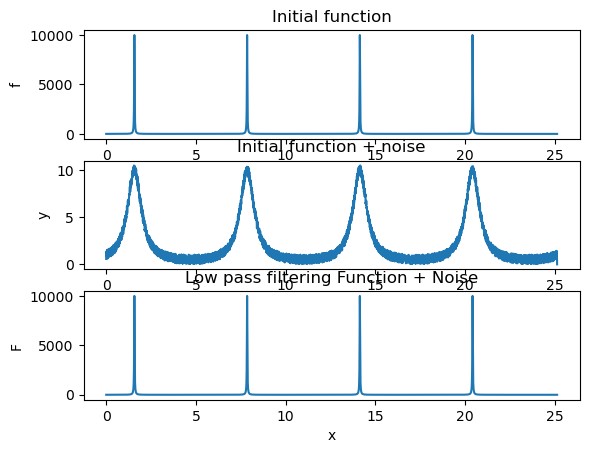

In [8]:
### NoiseSincFilter.py

from __future__ import division,print_function
from IPython.display import IFrame
from numpy import *
import random

import numpy as np
import matplotlib.pyplot as plt

max = 4000
array = np.zeros((max+1),float)
ps = np.zeros((max),float)
f = np.zeros((max + 1),float) 
y = np.zeros((max+1),float)
step = 2*np.pi/1000

def function():
   
    step = 2*np.pi/1000; x = 0. 
    for i in range(0,max):
        f[i] = 1/(1. - 0.9999*np.sin(x))                            # Initial function
        # function + random noise
        array[i] = (1./(1.- 0.9*np.sin(x))) + 0.5*(2.*random.random()-1.) 
        #funct1.plot(pos=(x,f[i]))
        #funct2.plot(pos=(x,array[i]))
        x += step
function()                    # call function 
maxx=8*np.pi
x=arange(0,maxx+step,step)
plt.subplot(3,1,1)
plt.plot(x,f)
plt.title('Initial function')
plt.xlabel('x')
plt.ylabel('f')
plt.subplot(3,1,2)
plt.plot(x,array)
plt.title('Initial function + noise')
plt.xlabel('x')
plt.ylabel('y')
def filter():
    #Low-pass windowed - sinc filter
    h = np.zeros((max),float)
    step = 2*np.pi/1000
    m = 100                              # Set filter length (101 points)
    fc = .07   
    for i in range(0,100):
        #Calculate low-pass filter kernel
        if ((i-(m/2)) == 0):
            h[i] = 2*np.pi*fc 
        if ((i-(m/2))!= 0):
            h[i] = np.sin(2*np.pi*fc*(i-m/2))/(i-m/2)
        h[i] = h[i]*(0.54 - 0.46*np.cos(2*np.pi*i/m))        #Hamming window
    
    sum = 0.                             # Normalize low-pass filter kernel
    for i in range(0,100):
        sum = sum + h[i]
    for i in range(0,100):
        h[i] = h[i] / sum 
    for j in range(100,max-1):
        #Convolve input with filter
        y[j] = 0.                    
        for i in range(0,100):
            y[j] = y[j] + array[j-i] * h[i]
    
    #for j in range(0,max-1):
    #    funct3.plot(pos=(j*step,y[j]))


filter()                               # call filter
maxj=8*np.pi
jj=arange(0,maxj+step,step)
plt.subplot(3,1,3)
plt.plot(jj,f)
plt.title('Low pass filtering Function + Noise')
plt.xlabel('x')
plt.ylabel('F')
plt.show()   
    

## 12.9  The Fast Fourier Transform Algorithm $\odot$ <a id="12.9"></a>

[![image](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/FFT/FFT.html)

We have seen in (12.37) that a discrete Fourier transform can be written
in the compact form

$$\tag*{12.81} Y_{n} = \frac{1} { \sqrt{2\pi}} \sum_{k=1}^N Z^{nk} y_k,
\quad Z = e^{-2\pi i/N},\quad n=0,1,\ldots, N-1.$$

Even if the signal elements $y_k$ to be transformed are real, $Z$ is
complex, and therefore we must process both real and imaginary parts
when computing transforms. Because both $n$ and $k$ range over $N$
integer values, the $(Z^n)^k  y_k$ multiplications in (12.81) require
some $N^2$ multiplications and additions of complex numbers. As $N$ gets
large, as happens in realistic applications, this geometric increase in
the number of steps leads to long computation times.

In 1965, Cooley and Tukey discovered an algorithm\[*Note:* Actually,
this algorithm has been discovered a number of times, for instance, in
1942 by Danielson and Lanczos \[[Danielson & Lanczos(42))](BiblioLinked.html#dala)\], as well as
much earlier by Gauss.\] that reduces the number of operations necessary
to perform a DFT from $N^2$ to roughly $N \log_2 N$ \[Cooley(65),
Donnelly & Rust(05)\]. Although this may not seem like such a big
difference, it represents a 100-fold speedup for 1000 data points, which
changes a full day of processing into 15 min of work. Because of its
widespread use (including cell phones), the fast Fourier transform
algorithm is considered one of the 10 most important algorithms of all
time.

The idea behind the FFT is to utilize the periodicity inherent in the
definition of the DFT (12.81) to reduce the total number of
computational steps. Essentially, the algorithm divides the input data
into two equal groups and transforms only one group, which requires
$\sim(N/2)^2$ multiplications. It then divides the remaining
(nontransformed) group of data in half and transforms them, continuing
the process until all the data have been transformed. The total number
of multiplications required with this approach is approximately
$N \log_2 N$.

Specifically, the FFT’s time economy arises from the computationally expensive
complex factor $Z^{nk} [= ((Z)^n)^k]$ having values that are repeated as the
integers $n$ and $k$ vary sequentially. For instance, for $N=8$,[{xml}](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/12.83.xml) 

$$\begin{align}
 Y_0& = Z^0y_0 + Z^0 y_1 + Z^{0\ } y_2+ Z^{0\ } y_3+ Z^{0\ } y_4+
 Z^{0\ } y_5+Z^{0\ }y_6+ Z^{0\ } y_7,  \\
Y_1 & = Z^0y_0+Z^1y_1 +Z^2y_2 +Z^{3\ }y_3 +Z^{4\ }y_4+Z^{5\ }y_5+Z^{6\
}y_6+Z^{7\ }y_7,\\
 Y_2 & =  Z^0y_0+Z^2y_1 +Z^{4\ }
 y_2 +Z^{6\ }y_3 +Z^{8\ }y_4+Z^{10}y_5+Z^{12}y_6+Z^{14}y_7,   \\
 Y_3 & =  Z^0y_0+Z^3y_1 +Z^{6\ } y_2 +Z^{9\ }y_3
+Z^{12}y_4+Z^{15}y_5+Z^{18}y_6+Z^{21}y_7, \\
 Y_4 & =
Z^0y_0+Z^4y_1 +Z^{8\ } y_2 +Z^{12}y_3
+Z^{16}y_4+Z^{20}y_5+Z^{24}y_6+Z^{28}y_7, \\
 Y_5 & =
Z^0y_0+Z^5y_1 +Z^{10} y_2+Z^{15}y_3
+Z^{20}y_4+Z^{25}y_5+Z^{30}y_6+Z^{35}y_7, \\
 Y_6 & =
Z^0y_0+Z^6y_1 +Z^{12} y_2+Z^{18}y_3
+Z^{24}y_4+Z^{30}y_5+Z^{36}y_6+Z^{42}y_7, \\
 Y_7 & =  Z^0y_0+Z^7y_1 +Z^{14} y_2+Z^{21}y_3
+Z^{28}y_4+Z^{35}y_5+Z^{42}y_6+Z^{49}y_7,\end{align}$$ 

where we include
$Z^0 ({\equiv}1)$ for clarity. When we actually evaluate these powers of $Z$,
we find only four independent values:

$$\tag*{12.82}
\begin{array}{ll}
Z^0 = \exp{(0)} = +1, & Z^1 = \exp(-\frac{2\pi}{8}) = +
\frac{\sqrt{2}} {2}-i  \frac{\sqrt{2}} {2}, \\
Z^2 = \exp(- \frac{2\cdot 2i\pi } {8}) = -i, & Z^3 = \exp(- \frac{2\pi\cdot3i}{ 8}) = -
\frac{\sqrt{2}}{2}-i \frac{\sqrt{2}}{2},\\ Z^4 = \exp(- \frac{2\pi\cdot4i}{8}) = -Z^0,
& Z^5 = \exp(- \frac{2\pi\cdot5i}{8}) = -Z^1, \\ Z^6 = \exp(-
\frac{2\cdot6i\pi}{8}) = -Z^2, & Z^7 =
\exp(-\frac{2\cdot7i\pi}{8}) = -Z^3,\\
Z^8 = \exp(- \frac{2\pi\cdot 8i}{8}) = +Z^0, & Z^9 =
\exp(-\frac{2\pi\cdot9i}{8}) = +Z^1, \\
Z^{10} = \exp(- \frac{2\pi\cdot10i}{8}) = +Z^2, & Z^{11} =
\exp(-\frac{2\pi\cdot11i}{ 8}) = +Z^3, \\
 Z^{12} = \exp(- \frac{2\pi\cdot11i}{8}) = -Z^0, &\qquad \cdots .
\end{array}$$

When substituted into the definitions of the transforms, we obtain

$$\begin{align}
\tag*{12.83}
Y_0& = Z^0 y_0 + Z^0 y_1 + Z^0 y_2+ Z^0 y_3+ Z^0 y_4+ Z^0 y_5+ Z^0 y_6+ Z^0
y_7, \\
Y_1 & = Z^0y_0+Z^1y_1 +Z^2y_2 +Z^3y_3
-Z^0y_4-Z^1y_5-Z^2y_6-Z^3y_7,\tag*{12.84}\\
Y_2 & = Z^0y_0+Z^2y_1 -Z^0 y_2
-Z^2y_3 +Z^0y_4+Z^2y_5-Z^0y_6-Z^2y_7,\tag*{12.85}\\
Y_3 & = Z^0y_0+Z^3y_1 -Z^2 y_2 +Z^1y_3 -Z^0y_4-Z^3y_5+Z^2y_6-Z^1y_7,\tag*{12.86}\\ 
Y_4 & = Z^0y_0-Z^0y_1 +Z^0 y_2 -Z^0y_3 +Z^0y_4-Z^0y_5+Z^0y_6-Z^0y_7,\tag*{12.87}\\
Y_5 & = Z^0y_0-Z^1y_1 +Z^{2} y_2-Z^3y_3 -Z^0y_4+Z^1y_5-Z^2y_6+Z^3y_7,\tag*{12.88}\\
Y_6 & = Z^0y_0-Z^2y_1 -Z^0 y_2+Z^2y_3 +Z^0y_4-Z^2y_5-Z^0y_6+Z^2y_7,\tag*{12.89}\\
Y_7 & = Z^0y_0-Z^3y_1 -Z^2y_2-Z^1y_3 -Z^0y_4+Z^3y_5+Z^2y_6+Z^1y_7,\tag*{12.90}\\
Y_8& = Y_0.\tag*{12.91}
 \end{align}$$

We see that these transforms now require $8 \times 8=64$ multiplications of
complex numbers, in addition to some less time-consuming additions. We place
these equations in an appropriate form for computing by regrouping the terms
into sums and differences of the $y$’s:

$$\begin{align} 
Y_0& = Z^0(y_0 +y_4)
+Z^0(y_1+y_5)+Z^0(y_2+y_6)+Z^0(y_3+y_7),\tag*{12.92}\\
Y_1 & = Z^0(y_0-y_4) +Z^1(y_1-y_5)+Z^2(y_2-y_6)+Z^3(y_3-y_7),\tag*{12.93}\\
Y_2 & = Z^0(y_0+y_4)+Z^2(y_1+y_5)-Z^0(y_2+y_6)-Z^2(y_3+y_7),\tag*{12.94}\\
Y_3 & = Z^0(y_0-y_4) +Z^3(y_1-y_5)-Z^2(y_2-y_6)+Z^1(y_3-y_7),\tag*{12.95}\\
Y_4 & = Z^0(y_0+y_4)-Z^0(y_1+y_5)+Z^0(y_2+y_6)-Z^0(y_3+y_7),\tag*{12.96}\\
Y_5 & = Z^0(y_0-y_4) -Z^1(y_1-y_5)+Z^2(y_2-y_6)-Z^3(y_3-y_7),\tag*{12.97}\\
Y_6 & =  Z^0(y_0+y_4)-Z^2(y_1+y_5)-Z^0(y_2+y_6)+Z^2(y_3+y_7),\tag*{12.98}\\
Y_7 & = Z^0(y_0-y_4) -Z^3(y_1-y_5)-Z^2(y_2-y_6)-Z^1(y_3-y_7), \tag*{12.99}\\
 Y_8& = Y_0.\tag*{12.100}
 \end{align}$$
 
 Note the repeating factors inside the parentheses, with
combinations of the form $y_p\pm y_q$. These symmetries are systematized
by introducing the *butterfly operation* (Figure 12.8). This operation
takes the $y_p$ and $y_q$ data elements from the left wing and converts
them to the $y_p+Z y_q$ elements in the right wings. In Figure 12.9 we
show what happens when we apply the butterfly operations to an entire
FFT process, specifically to the pairs $(y_0, y_4)$, $(y_1, y_5)$,
$(y_2, y_6)$, and $(y_3, y_7)$. Notice how the number of multiplications
of complex numbers has been reduced: For the first butterfly operation
there are 8 multiplications by $Z^0$; for the second butterfly operation
there are 8 multiplications, and so forth, until a total of 24
multiplications are made in four butterflies. In contrast, 64
multiplications are required in the original DFT (12.90).

![image](Figs/Fig12_8.png)

**Figure 12.8** The basic butterfly operation in which elements
$\textit{y}_\textit{p}$ and $\textit{y}_\textit{q}$ on the left are transformed
into $\textit{y}_\textit{p} + \textit{Z y}_\textit{q}$ and $\textit{y}_\textit{p}-
\textit{Z y}_\textit{q}$ on the right.

### 12.9.1  Bit Reversal<a id="12.9.1"></a>

The reader may have observed in Figure 12.9 that we started with 8 data
elements in the order 0-7 and that after three butterfly operators we
obtained transforms in the order 0, 4, 2, 6, 1, 5, 3, 7. The astute
reader may further have observed that these numbers correspond to the
bit-reversed order of 0-7. Let us look into this further. We need 3 bits
to give the order of each of the 8 input data elements (the numbers
0-7). Explicitly, on the left in Table 10.1 we give the binary
representation for decimal numbers 0-7, their bit reversals, and the
corresponding decimal numbers. On the right we give the ordering for 16
input data elements, where we need 4 bits to enumerate their order.
Notice that the order of the first 8 elements differs in the two cases
because the number of bits being reversed differs. Notice too that after
the reordering, the first half of the numbers are all even and the
second half are all odd.

![image](Figs/Fig12_9.png)

**Figure 12.9** The butterfly operations performing a FFT on the eight data on
the left leading to eight transforms on the right. The transforms are different
linear combinations of the input data.

The fact that the Fourier transforms are produced in an order
corresponding to the bit-reversed order of the numbers 0-7 suggests that
if we process the data in the bit-reversed order 0, 4, 2, 6, 1, 5, 3, 7,
then the output Fourier transforms will be ordered (see Table 10.1). We
demonstrate this conjecture in Figure 12.10, where we see that to obtain
the Fourier transform for the eight input data, the butterfly operation
had to be applied three times. The number 3 occurs here because it is
the power of 2 that gives the number of data; that is, $2^3=8$. In
general, in order for a FFT algorithm to produce transforms in the
proper order, it must reshuffle the input data into bit-reversed order.
As a case in point, our sample program starts by reordering the 16
($2^4$) data elements given in Table 12.1. Now the four butterfly
operations produce sequentially ordered output.

| | |*Binary-Reversed* | 0-7 | *Binary-Reversed*| 0-16| 
|:- - -:|:- - -:|:- - -:|:- - -:|:- - -:|:- - -:| 
|<span>*Dec*</span>|<span>*Bin*</span> |<span>*Rev*</span> |<span>*Dec Rev*</span> |<span>*Rev*</span> |<span>*Dec Rev*</span>| 
| 0|000 |000 | 0 |0000 | 0| 
| 1|001 |100 | 4 |1000 | 8 | 
|2|010 |010 | 2 |0100 | 4 | 
| 3|011 |110 | 6 |1100 | 12 | 
| 4|100 |001 | 1 |0010 | 2 | 
| 5|101 |101 | 5 |1010 | 10 | 
| 6|110 |011 | 3 |0110 | 6 | 
| 7|111 |111 | 7 |1110 | 14 | 
| 8 |1000|- - -|- |0001 | 1| 
|9 |1001 |- - -| - |1001 | 9| 
|10 |1010 |- - -| - |0101 | 5| 
|11 |1011 |- - -| - |1101 | 13 | 
|12 | 1100 |- - -| - |0011 | 3| 
|13 |1101 |- - -| - |1011 | 11 |
|14 |1101 |- - -| - |0111 | 7| 
|15 |1111 |- - -| - |1111 | 15 |

## 12.10  FFT Implementation <a id="12.10"></a>

The first FFT program we are aware of was written in 1967 in Fortran IV
by Norman Brenner at MIT’s Lincoln Laboratory \[[Higgins(76))](BiblioLinked.html#higg)\] and was
hard for us to follow. Our (easier-to-follow) Python version is in
Listing 12.3. Its input is $N=2^n$ data to be transformed (FFT’s always
require that the number of input data are a power of 2). If the number
of your input data is not a power of 2, then you can make it so by
concatenating some of the initial data to the end of your input until a
power of 2 is obtained; because a DFT is always periodic, this just
starts the period a little earlier. Our program assigns complex numbers
at the 16 data points reorders the data via bit reversal, and then makes
four butterfly operations. The data are stored in the array
`dtr[max,2]`, with the second subscript denoting real and imaginary
parts. We increase speed further by using the 1-D array `data` to make
memory access more direct:

![image](Figs/Fig12_10.png)

**Figure 12.10** A modified FFT in which the eight input data on the left are
transformed into eight transforms on the right. The results are the same as in
the previous figure, but now the output transforms are in numerical order
whereas in the previous figure the input signals were in numerical order.

$$\tag*{12.101} y_m =m + m i, \qquad m=0,\ldots ,15,$$

**Table 12.1** Reordering for 16 Data Complex Points.

| Order |Input Data |New Order | 
|:- - -:|:- - -:|:- - -:| 
|0|0.0  +  0.0*i* | 0.0  + 0.0*i* | 
|1|1.0  +  1.0*i* | 8.0  +  8.0*i* | 
|2|2.0  +  2.0*i* | 4.0  +  4.0*i* |
|3|3.0  +  3.0*i* | 12.0  +  12.0*i* | 
|4|4.0  +  4.0*i* | 2.0  +  2.0*i* | 
|5|5.0  +  5.0*i* | 10.0  +  10.*i* | 
|6|6.0  +  6.0*i* | 6.0  +  6.0*i* | 
|7|7.0  +  7.0*i* | 14.0  +  14.0*i* | 
|8|8.0  +  8.0*i* | 1.0  +  1.0*i*| 
|9|9.0  +  9.0*i* | 9.0  +  9.0*i*| 
|10|10.0  +  10.*i* | 5.0  +  5.0*i*| 
|11|11.0  +  11.0*i* | 13.0  +  13.0*i*| 
|12|12.0  +  12.0*i* | 3.0  +  3.0*i*| 
|13|13.0   +  13.0*i* | 11.0  +  11.0*i*| 
|14|14.0  +  14.*i* | 7.0  +  7.0*i*| 
|15|15.0  +  15.0*i* | 15.0  +  15.0*i*| 

$$\tag*{12.102}
data[1] = dtr[0,1], \quad {data}[2] =  {dtr}[1,1], \quad  {data}[3] =  {dtr}[1,0],
\ldots\ ,$$

which also provides storage for the output. The FFT transforms `data`
using the butterfly operation and stores the results back in `dtr[,]`,
where the input data were originally.

In [ ]:
### FFT.[y, Notebook Version]

In [9]:
# FFT.[y, Notebook Version]
''' Illustrates the process to find the Fast Fourier Transform
for complex numbers dtr[][]
data1[i][0], data1[i][1] = Re, Im parts of point [i].
When done, Re, Im Fourier Transforms placed in same array 
Required max = 2^m < 1024
dtr[][] placed in array data[]. '''

from numpy import *

max=2100                 
points=1026                                # Can be increased
data = zeros((max),float) 
dtr= zeros((points,2),float)
  
def fft(nn,isign):                     # FFT of dtr[n,2]
    n=2*nn
    for i in range(0,nn+1):        # Original data in dtr to data
        j=2*i+1
        data[j] = dtr[i,0]      # Real dtr, odd data[j]
        data[j+1] = dtr[i,1]    # Imag dtr, even data[j+1]
    j = 1                              # Place data in bit reverse order
    for i in range(1,n+2,2 ):
        if (i-j)<0 :                   # Reorder equivalent to bit reverse
            tempr = data[j]
            tempi = data[j+1]
            data[j] = data[i]
            data[j+1] = data[i+1]
            data[i] = tempr
            data[i+1] = tempi 
        m = n/2;
        while (m-2>0): 
            if  (j-m)<=0 :
                break
            j = j-m
            m = m/2
        j = j+m;
                               
    print(" Bit-reversed data ")
  
    for i in range(1,n+1,2):
        print("%2d  data[%2d]  %9.5f "%(i,i,data[i]))# Print to see reorder
    mmax = 2
    while (mmax-n)<0 :            # Begin transform
        istep = 2*mmax
        theta = 6.2831853/(1.0*isign*mmax)
        sinth = math.sin(theta/2.0)
        wstpr = -2.0*sinth**2
        wstpi = math.sin(theta)
        wr = 1.0
        wi = 0.0
        for m in range(1,mmax +1,2):  
            for i in range(m,n+1,istep):
                j = i+mmax
                tempr = wr*data[j]-wi*data[j+1]
                tempi = wr*data[j+1]+wi*data[j]
                data[j] = data[i]-tempr
                data[j+1] = data[i+1]-tempi
                data[i] = data[i]+tempr
                data[i+1] = data[i+1]+tempi        
            tempr = wr
            wr = wr*wstpr-wi*wstpi+wr
            wi = wi*wstpr+tempr*wstpi+wi;
        mmax = istep              
    for i in range(0,nn):
        j = 2*i+1
        dtr[i,0] = data[j]
        dtr[i,1] = data[j+1] 
nn = 16                            # Power of 2                                      
isign = -1                    # -1 transform, +1 inverse transform
print('        INPUT')
print("  i   Re part   Im  part")
for i in range(0,nn ):        # Form array
    dtr[i,0] = 1.0*i           # Real part
    dtr[i,1] = 1.0*i           # Im part
    print(" %2d %9.5f %9.5f" %(i,dtr[i,0],dtr[i,1]))
fft(nn, isign)          # Call FFT, use global dtr[][]
print('    Fourier transform')
print("  i      Re      Im    ")
for i in range(0,nn):  
    print(" %2d  %9.5f  %9.5f "%(i,dtr[i,0],dtr[i,1]))

        INPUT
  i   Re part   Im  part
  0   0.00000   0.00000
  1   1.00000   1.00000
  2   2.00000   2.00000
  3   3.00000   3.00000
  4   4.00000   4.00000
  5   5.00000   5.00000
  6   6.00000   6.00000
  7   7.00000   7.00000
  8   8.00000   8.00000
  9   9.00000   9.00000
 10  10.00000  10.00000
 11  11.00000  11.00000
 12  12.00000  12.00000
 13  13.00000  13.00000
 14  14.00000  14.00000
 15  15.00000  15.00000


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## 12.11  FFT Assessment<a id="12.11"></a>

1.  Compile and execute `FFT.py`. Make sure you understand the output.

2.  Take the output from `FFT.py`, inverse-transform it back to signal
    space, and compare it to your input. \[Checking that the double
    transform is proportional to itself is adequate, although the
    normalization factors in (12.37) should make the two equal.\]

3.  Compare the transforms obtained with a FFT to those obtained with a
    DFT (you may choose any of the functions studied before). Make sure
    to compare both precision and execution times.

[**Listing 12.3  FFT.py**](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/FFT.py) computes the FFT or inverse transform depending
upon the sign of `isign`.